
#### AIRLINE PASSENGER SATISFACTION DATASET
#### KAGGLE LINK: https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LogisticRegression

# Load data and display the first few rows:
import kagglehub


path = kagglehub.dataset_download("teejmahal20/airline-passenger-satisfaction")

print("Path to dataset files:", path)
df = pd.read_csv(f"{path}/train.csv")

Path to dataset files: /Users/furkancanercan/.cache/kagglehub/datasets/teejmahal20/airline-passenger-satisfaction/versions/1


### Variables: 
    Gender: Gender of the passengers (Female, Male)

    Customer Type: The customer type (Loyal customer, disloyal customer)

    Age: The actual age of the passengers

    Type of Travel: Purpose of the flight of the passengers (Personal Travel, Business Travel)

    Class: Travel class in the plane of the passengers (Business, Eco, Eco Plus)

    Flight distance: The flight distance of this journey

    Inflight wifi service: Satisfaction level of the inflight wifi service (0:Not Applicable;1-5)

    Departure/Arrival time convenient: Satisfaction level of Departure/Arrival time convenient

    Ease of Online booking: Satisfaction level of online booking

    Gate location: Satisfaction level of Gate location

    Food and drink: Satisfaction level of Food and drink

    Online boarding: Satisfaction level of online boarding

    Seat comfort: Satisfaction level of Seat comfort

    Inflight entertainment: Satisfaction level of inflight entertainment

    On-board service: Satisfaction level of On-board service

    Leg room service: Satisfaction level of Leg room service

    Baggage handling: Satisfaction level of baggage handling

    Check-in service: Satisfaction level of Check-in service

    Inflight service: Satisfaction level of inflight service

    Cleanliness: Satisfaction level of Cleanliness

    Departure Delay in Minutes: Minutes delayed when departure

    Arrival Delay in Minutes: Minutes delayed when Arrival

    Satisfaction: Airline satisfaction level (Satisfaction, neutral or dissatisfaction)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

### DATA PREPROCESSING

In [41]:
df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,51951.500000,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,29994.645522,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [42]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [43]:
df.drop(['Unnamed: 0','id'], axis=1,inplace = True)

In [44]:
df.isnull().sum()

Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction                           0
dtype: int64

##### 310 NULL VALUES. Lets Investigate

In [45]:
df["Arrival Delay in Minutes"].describe()

count    103594.000000
mean         15.178678
std          38.698682
min           0.000000
25%           0.000000
50%           0.000000
75%          13.000000
max        1584.000000
Name: Arrival Delay in Minutes, dtype: float64

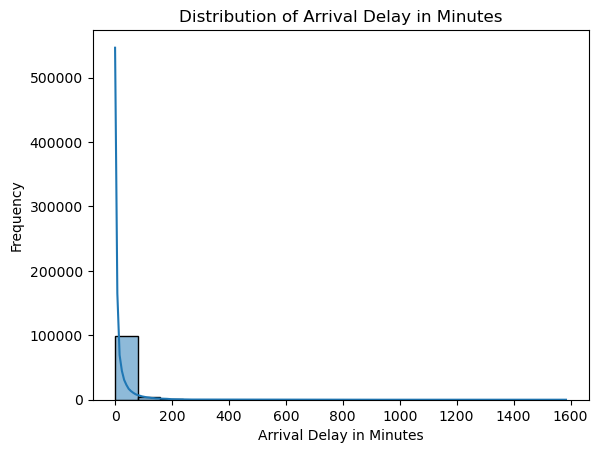

Count: 103594


In [46]:
hist = sns.histplot(df['Arrival Delay in Minutes'], bins=20, kde=True)
plt.title('Distribution of Arrival Delay in Minutes')
plt.xlabel('Arrival Delay in Minutes')
plt.ylabel('Frequency')
plt.show()
print('Count:', df['Arrival Delay in Minutes'].count())

##### Looking at the distribution plot for the Arrival Delay variable, we can see that arrival delays are generally between 0 and 200 minutes. 
##### * The average delay is around 15 minutes, but extreme delays such as 1584 minutes also exist. 
##### * Before dealing with outliers, we should first decide which variables to drop based on VIF, Correlation, and similar metrics.
##### * Since only 310 out of 103594 records are missing and given the structure of the data, filling with the median is a reasonable approach.

In [47]:
df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].mean(), inplace=True)
df.isnull().sum()

Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64

In [48]:
for i in range(len(df.columns)):
    print(df.columns[i],' = ',df.iloc[:, i].dtype)

Gender  =  object
Customer Type  =  object
Age  =  int64
Type of Travel  =  object
Class  =  object
Flight Distance  =  int64
Inflight wifi service  =  int64
Departure/Arrival time convenient  =  int64
Ease of Online booking  =  int64
Gate location  =  int64
Food and drink  =  int64
Online boarding  =  int64
Seat comfort  =  int64
Inflight entertainment  =  int64
On-board service  =  int64
Leg room service  =  int64
Baggage handling  =  int64
Checkin service  =  int64
Inflight service  =  int64
Cleanliness  =  int64
Departure Delay in Minutes  =  int64
Arrival Delay in Minutes  =  float64
satisfaction  =  object


In [49]:
df['satisfaction'].value_counts()


satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64

##### Looking at the distribution of our target variable, the proportion of satisfied customers is higher than dissatisfied ones, though the distribution can be considered somewhat imbalanced.

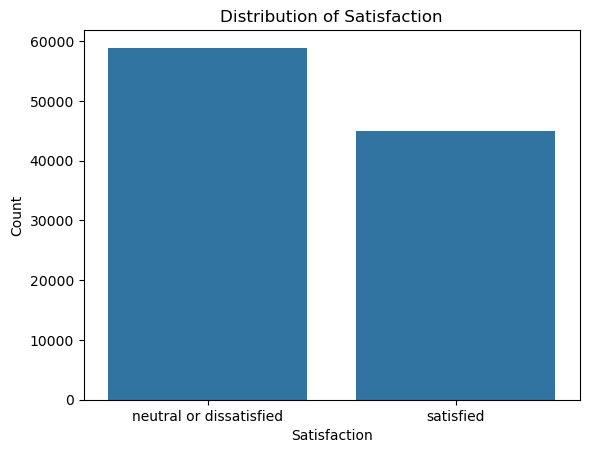

In [50]:
sns.countplot(x='satisfaction', data=df)
plt.title('Distribution of Satisfaction')
plt.xlabel('Satisfaction')
plt.ylabel('Count')
plt.show()

In [51]:
# Checking unique values of object-type columns and identifying which are categorical
for i in range(len(df.columns)):
    if df.iloc[:, i].dtype == 'object':
        print(df.columns[i], ' = ', df.iloc[:, i].unique())

Gender  =  ['Male' 'Female']
Customer Type  =  ['Loyal Customer' 'disloyal Customer']
Type of Travel  =  ['Personal Travel' 'Business travel']
Class  =  ['Eco Plus' 'Business' 'Eco']
satisfaction  =  ['neutral or dissatisfied' 'satisfied']


In [52]:
## Encoding the Satisfaction column as 0 and 1
df['satisfaction'] = df['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})

In [53]:
# Separating categorical and numerical columns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.to_list()
cat_cols = df.select_dtypes(include=['object']).columns.to_list()


In [54]:
cat_cols

['Gender', 'Customer Type', 'Type of Travel', 'Class']

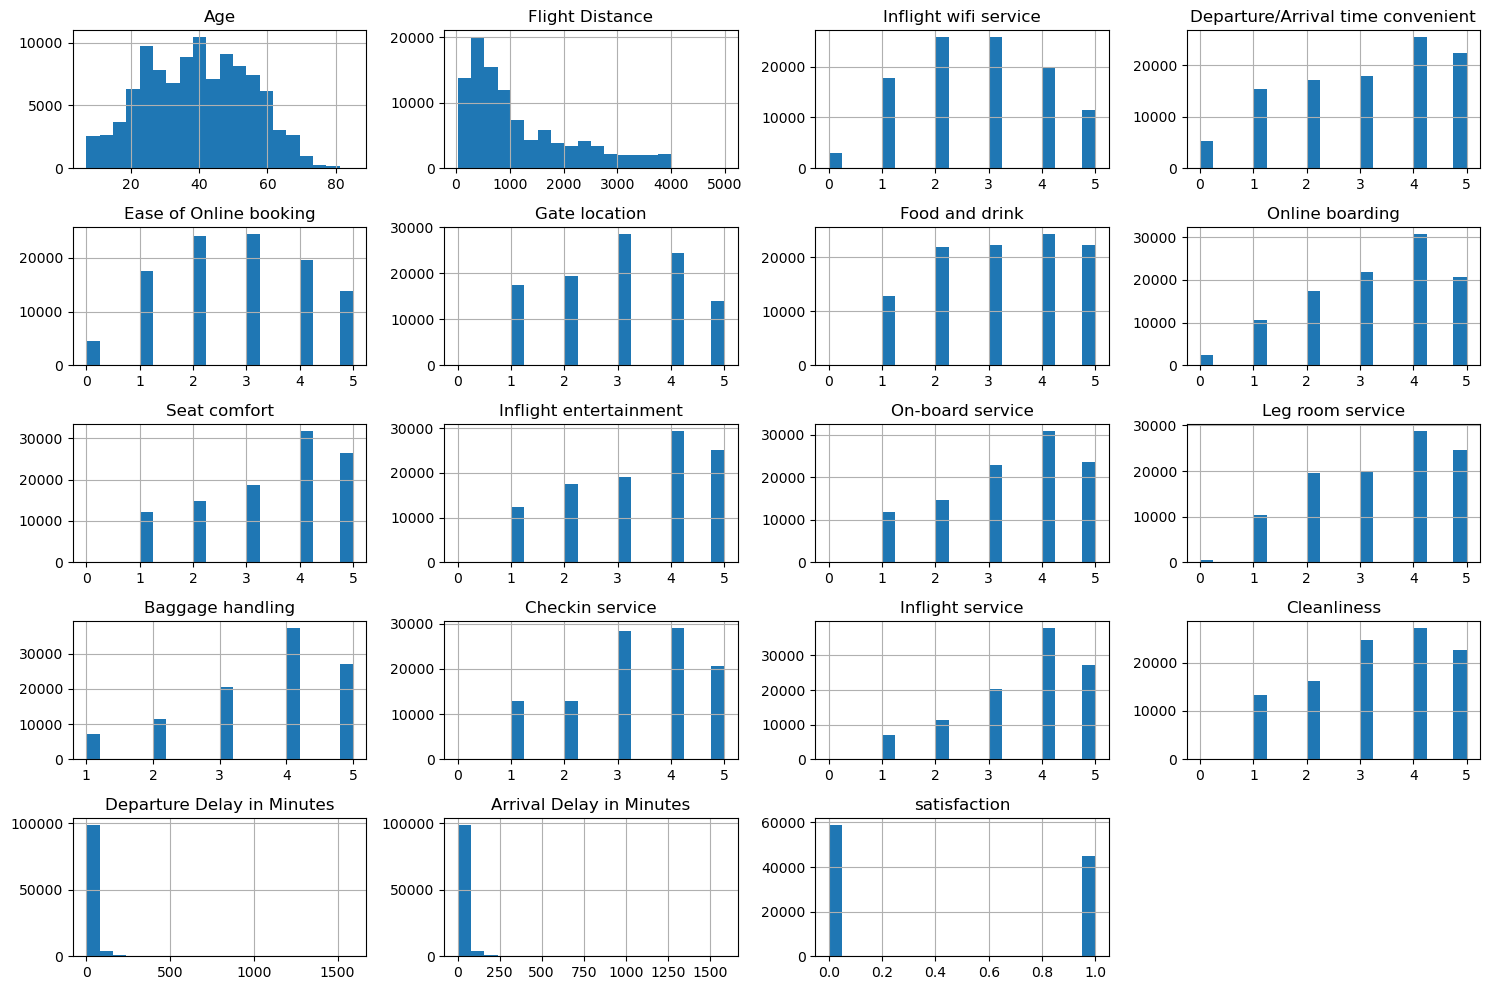

In [55]:
# Visualizing the distribution of numerical columns
df[num_cols].hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()


##### Here we can more clearly see that most of the numerical variables are ordinal, resembling survey results.
##### * We should also separate the ordinal variables.
##### * Other than that, the Departure Delay and Arrival Delay variables aside, there does not appear to be any particularly unexpected distribution in the data.

In [56]:
ordinal_cols = ['Class', 'Inflight Wifi Service', 'On-board Service', 'Leg Room Service', 'Baggage Handling',
                'Checkin Service', 'Cleanliness', 'Inflight Service', 'Food and Drink', 'Seat Comfort', 'Departure/Arrival Time Convenience',
                'Ease of Online Booking', 'Gate Location', 'Online Boarding', 'Inflight Entertainment']

In [57]:
num_cols

['Age',
 'Flight Distance',
 'Inflight wifi service',
 'Departure/Arrival time convenient',
 'Ease of Online booking',
 'Gate location',
 'Food and drink',
 'Online boarding',
 'Seat comfort',
 'Inflight entertainment',
 'On-board service',
 'Leg room service',
 'Baggage handling',
 'Checkin service',
 'Inflight service',
 'Cleanliness',
 'Departure Delay in Minutes',
 'Arrival Delay in Minutes',
 'satisfaction']

In [58]:
to_remove = [
    'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 
    'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 
    'Inflight entertainment', 'On-board service', 'Leg room service', 
    'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness'
]

# This creates a new list excluding any items found in 'to_remove'
num_cols = [col for col in num_cols if col not in to_remove]

In [59]:
num_cols

['Age',
 'Flight Distance',
 'Departure Delay in Minutes',
 'Arrival Delay in Minutes',
 'satisfaction']

In [60]:
ordinal_cols

['Class',
 'Inflight Wifi Service',
 'On-board Service',
 'Leg Room Service',
 'Baggage Handling',
 'Checkin Service',
 'Cleanliness',
 'Inflight Service',
 'Food and Drink',
 'Seat Comfort',
 'Departure/Arrival Time Convenience',
 'Ease of Online Booking',
 'Gate Location',
 'Online Boarding',
 'Inflight Entertainment']

In [61]:
cat_cols

['Gender', 'Customer Type', 'Type of Travel', 'Class']

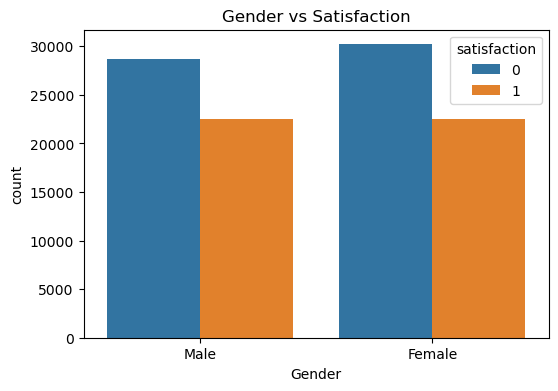

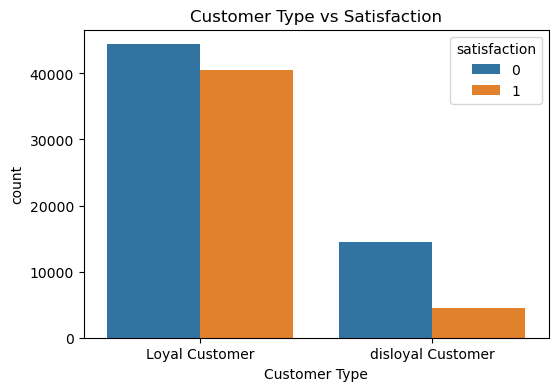

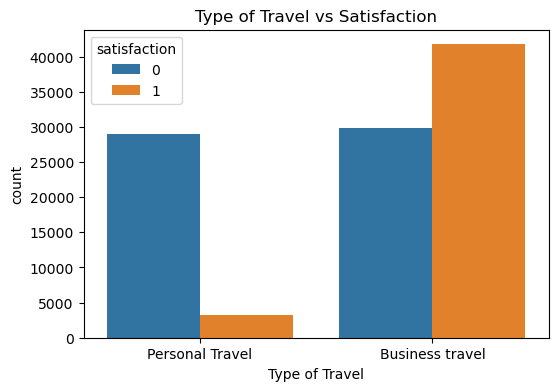

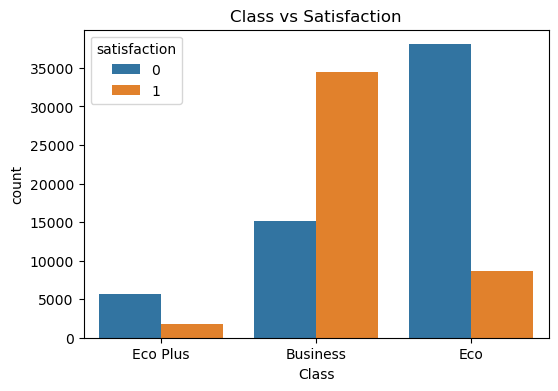

In [62]:
for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df, hue='satisfaction')
    plt.title(f'{col} vs Satisfaction')
    plt.show()

##### Looking at this, we can see that customer satisfaction levels are higher in higher-class segments like Business class.

#### Encoding categorical variables using One-Hot Encoding.
##### The reason we do it this way is that if we assign numeric values like 0, 1, 2 to categorical variables, models may interpret 0 as lower than 1 and try to find numerical differences between categories.
##### Instead, we treat each category as a separate binary variable using One-Hot Encoding.

In [63]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

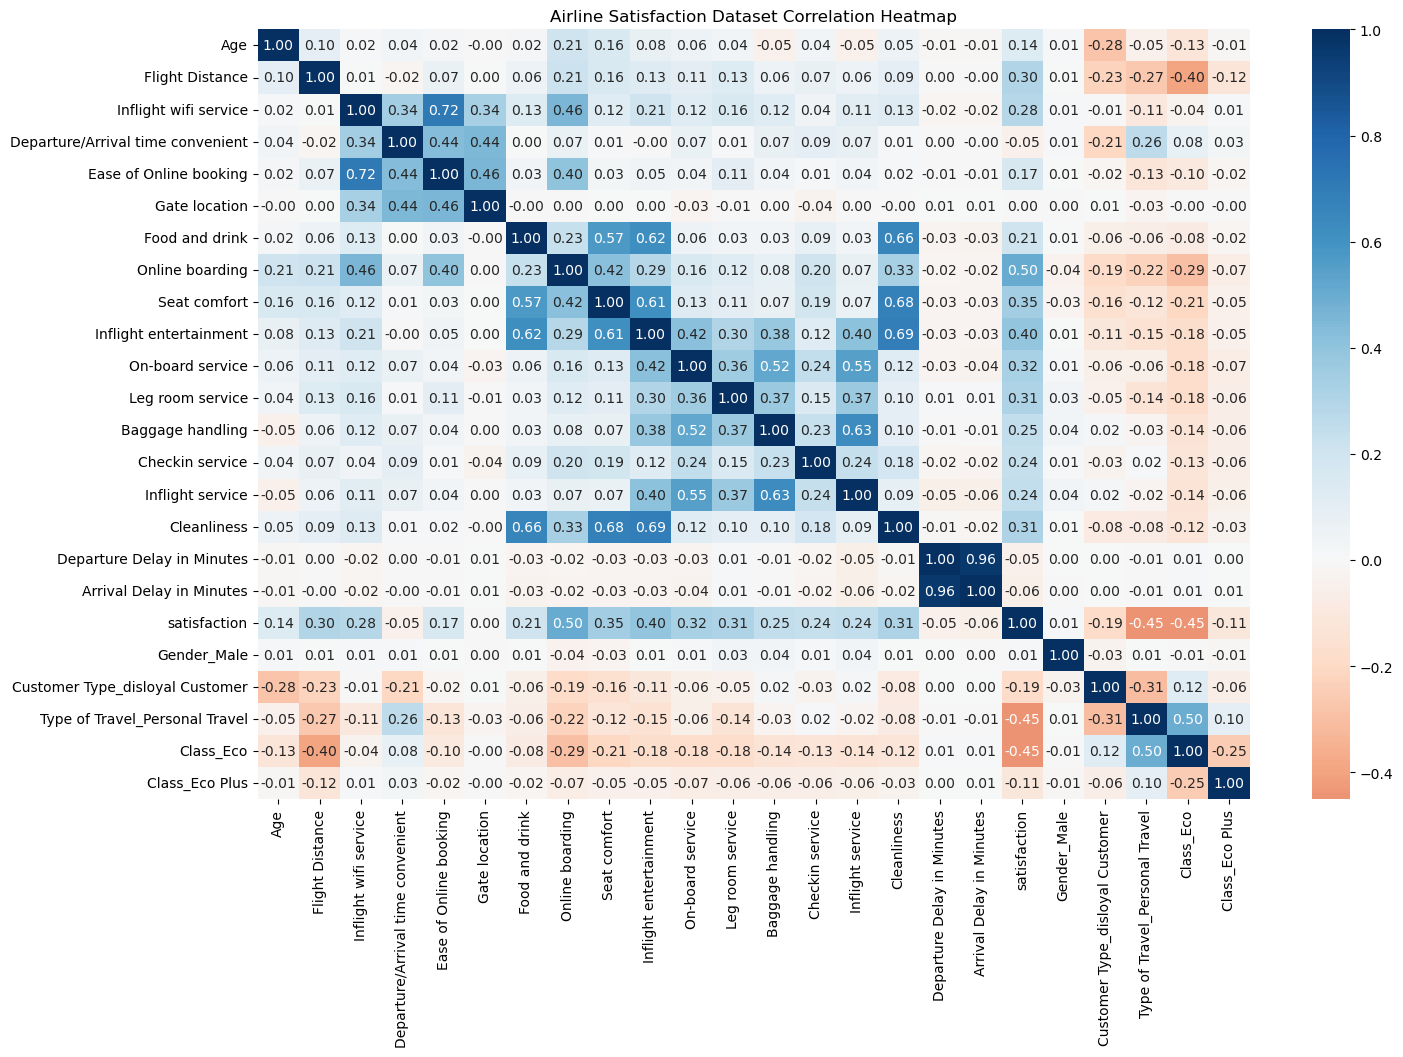

In [64]:
# Correlation Matrix
corr_matrix = df.select_dtypes(include=['int64', 'float64','bool']).corr()

plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu', center=0)
plt.title('Airline Satisfaction Dataset Correlation Heatmap')
plt.show()

#### No correlation value above ± 0.5 stands out for the satisfaction variable.
#### There is a very high correlation between Departure Delay In Minutes and Arrival Delay In Minutes.
#### Since simple linear models like Logistic Regression are vulnerable to Multicollinearity, we need to address variables with high correlation.

### VIF Values

In [65]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.select_dtypes(include=['int64', 'float64']).drop('satisfaction', axis=1)

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                              feature        VIF
9              Inflight entertainment  25.992744
14                   Inflight service  20.574334
15                        Cleanliness  20.309835
12                   Baggage handling  18.981695
8                        Seat comfort  18.346636
17           Arrival Delay in Minutes  15.153145
16         Departure Delay in Minutes  15.106528
10                   On-board service  13.796271
6                      Food and drink  13.676741
4              Ease of Online booking  12.934520
7                     Online boarding  12.744287
2               Inflight wifi service  12.513255
11                   Leg room service   9.465695
13                    Checkin service   9.293736
5                       Gate location   8.785841
0                                 Age   7.237425
3   Departure/Arrival time convenient   7.204099
1                     Flight Distance   2.647007


##### As expected, most of our ordinal variables have VIF values above 10.
##### Since Arrival and Departure Delay variables appear to create a multicollinearity issue with each other,
##### I will create a new variable called Total Delay, drop both of them separately, and then re-examine VIF values.

In [66]:
df['Total Delay'] = df['Departure Delay in Minutes'] + df['Arrival Delay in Minutes']
df.drop(['Departure Delay in Minutes', 'Arrival Delay in Minutes'], axis=1, inplace=True)


In [67]:
X_vif = df.select_dtypes(include=['int64', 'float64']).drop('satisfaction', axis=1)
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
print(vif_data.sort_values(by="VIF", ascending=False))

                              feature        VIF
9              Inflight entertainment  25.992315
14                   Inflight service  20.573972
15                        Cleanliness  20.309376
12                   Baggage handling  18.981324
8                        Seat comfort  18.346437
10                   On-board service  13.796251
6                      Food and drink  13.676668
4              Ease of Online booking  12.934519
7                     Online boarding  12.744227
2               Inflight wifi service  12.513251
11                   Leg room service   9.465645
13                    Checkin service   9.293662
5                       Gate location   8.785374
0                                 Age   7.237348
3   Departure/Arrival time convenient   7.203987
1                     Flight Distance   2.646595
16                        Total Delay   1.153206


##### Since models like Logistic Regression are very sensitive to high VIF values, I will proceed with PCA.
##### I plan to set the explained variance threshold to 90%.
##### Before that, we need to check for outliers.

### Outlier Detection

##### We have 2 variables that may contain outliers: Total Delay and Flight Distance. The remaining variables
##### are generally ordinal or boolean types.

In [68]:
def detect_outliers_iqr(df, columns):
    outlier_indices = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Finding the indices of outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
        outlier_indices.extend(outliers)
        
        print(f"{col} - Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
        print(f"Number of outliers in column {col}: {len(outliers)}")
    
    return list(set(outlier_indices))

# Columns to check
check_cols = ['Flight Distance', 'Total Delay',]
outlier_list = detect_outliers_iqr(df, check_cols)


Flight Distance - Lower Bound: -1579.50, Upper Bound: 3736.50
Number of outliers in column Flight Distance: 2291
Total Delay - Lower Bound: -36.00, Upper Bound: 60.00
Number of outliers in column Total Delay: 14299


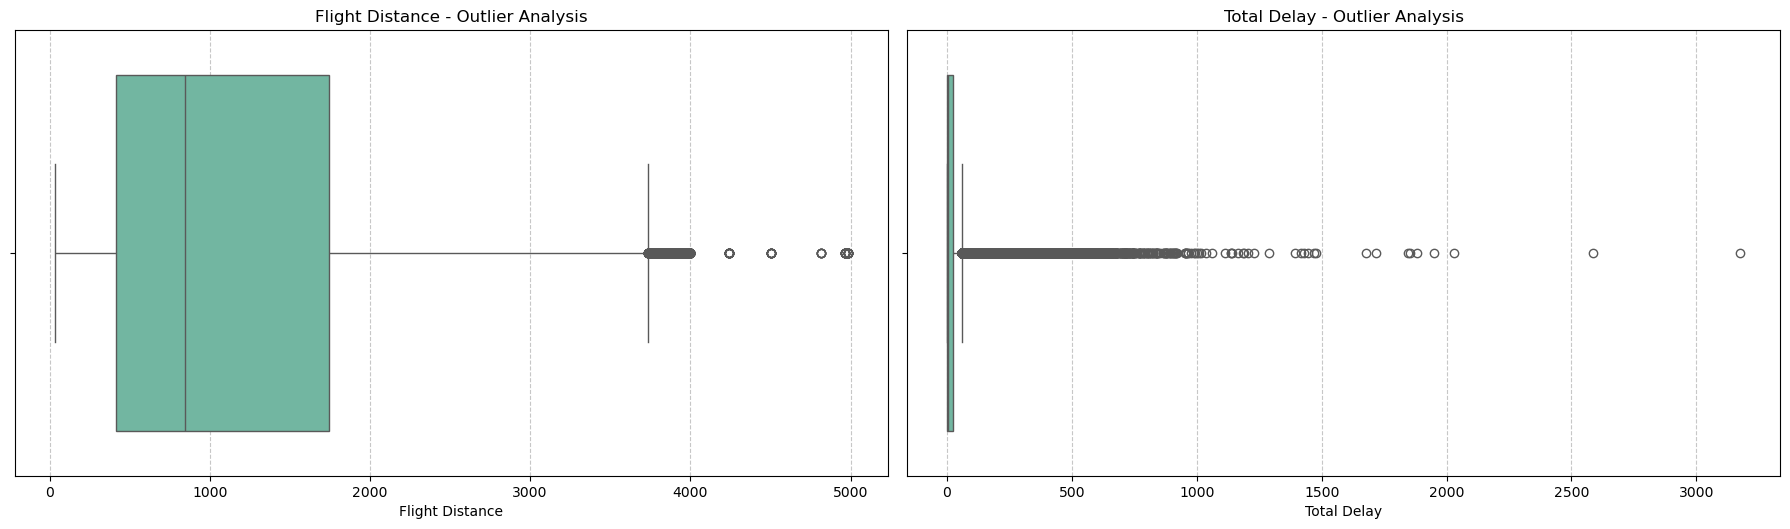

In [69]:
plt.figure(figsize=(18, 10))

for i, col in enumerate(check_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col], palette="Set2")
    plt.title(f'{col} - Outlier Analysis')
    plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

##### Both variables contain many outliers.
##### Instead of dropping them directly, I will proceed with Capping.
##### Capping: Allows us to set all values above the upper bound (e.g. 300 minutes) to that threshold, preventing extreme values (like 1500 min) from dominating PCA and Logistic Regression.

In [70]:
def cap_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + 1.5 * IQR
        lower_bound = Q1 - 1.5 * IQR
        
        # Clip values within bounds (only upper bound exceeded values are critical for delays)
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df

# Apply only to flight distance and delays
df = cap_outliers(df, ['Flight Distance', 'Total Delay'])

### PCA and Standardization

In [71]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.select_dtypes(include=['int64', 'float64']).drop('satisfaction', axis=1))

pca = PCA(n_components=0.90)
print(pca.fit(X_scaled).explained_variance_ratio_)
print("Total Explained Variance Ratio:", sum(pca.explained_variance_ratio_))
print("Required Number of Components:", pca.n_components_)


[0.22699529 0.13898801 0.12814689 0.07325115 0.05908247 0.05661945
 0.05429587 0.05234962 0.04074484 0.03139624 0.02816692 0.02630983]
Total Explained Variance Ratio: 0.9163465570300466
Required Number of Components: 12


##### We can explain approximately 90% of the variance in the data with 12 components. I will proceed with this for Logistic Regression.

### Modeling Phase

In [72]:
X = df.drop('satisfaction', axis=1)
y = df['satisfaction']

In [73]:
# Train-Test Split
# 80% Training, 20% Test (for Validation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (83123, 22)
Test set size: (20781, 22)


In [74]:
X_pca = pca.transform(X_scaled)
# Prepare the target variable (assuming it was mapped earlier)
y = df['satisfaction']

# Split as 80% Training, 20% Test
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

#### LOGISTIC REGRESSION

In [75]:
# Define the model
# Increasing max_iter prevents convergence issues on large datasets
log_model = LogisticRegression(max_iter=1000)

# Train the model
log_model.fit(X_train_pca, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [77]:
from sklearn.metrics import f1_score,roc_auc_score,accuracy_score,precision_recall_curve,precision_score,recall_score
# Make predictions
y_pred = log_model.predict(X_test_pca)
y_proba = log_model.predict_proba(X_test_pca)[:, 1]

print("--- Logistic Regression (with PCA) Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

--- Logistic Regression (with PCA) Results ---
Accuracy: 0.8265
ROC-AUC: 0.8870

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85     11713
           1       0.82      0.78      0.80      9068

    accuracy                           0.83     20781
   macro avg       0.83      0.82      0.82     20781
weighted avg       0.83      0.83      0.83     20781



Confusion Matrix:


Text(0.5, 1.0, 'Confusion Matrix - Logistic Regression (with PCA)')

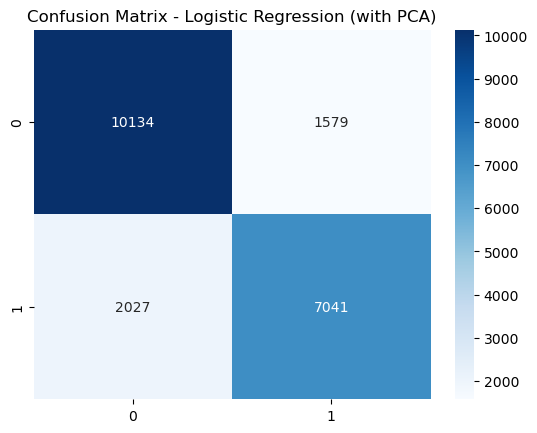

In [78]:
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression (with PCA)')

ROC Curve


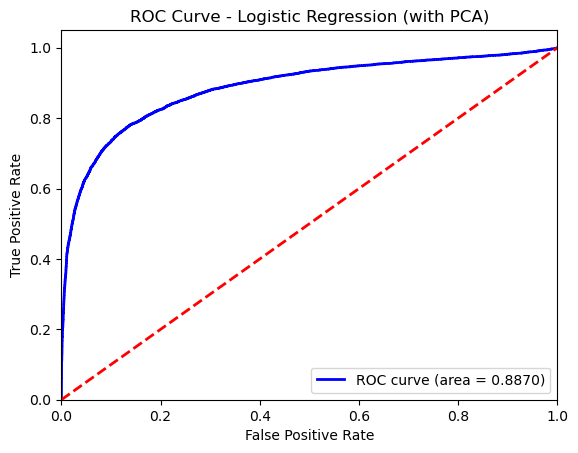

In [81]:
from sklearn.metrics import roc_curve,auc
print('ROC Curve')
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (with PCA)')
plt.legend(loc="lower right")

#### SVM 

In [82]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score



In [83]:
# Model definition
# Setting probability=True to get probability scores (required for ROC-AUC)
svm_model = SVC(probability=True, random_state=42)

##### Since SVM parameter search is very slow on datasets with 10,000+ rows, we will find the best parameters via sampling and then build the main model using those parameters.

In [84]:
# Select a representative sample of 15,000 rows from the training data
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train_pca, y_train, train_size=15000, random_state=42, stratify=y_train
)

In [85]:
# 2. Parameter Space (values to search over)
param_dist = {
    'C': [0.1, 1, 10, 100],             # Regularization tolerance
    'gamma': ['scale', 'auto', 0.1, 0.01], # Flexibility of the decision boundary
    'kernel': ['rbf', 'poly', 'sigmoid']  # Transformation function
}

# Randomized Search (trying 5 different combinations to save time)

random_search_svm = RandomizedSearchCV(
    svm_model, 
    param_distributions=param_dist, 
    n_iter=5, 
    cv=3, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=2, 
    random_state=42
)

In [86]:
random_search_svm.fit(X_train_sub, y_train_sub)
print(f"Best Parameters Found: {random_search_svm.best_params_}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END ..................C=10, gamma=scale, kernel=sigmoid; total time=  10.5s
[CV] END .......................C=10, gamma=auto, kernel=rbf; total time=  11.0s
[CV] END .......................C=10, gamma=auto, kernel=rbf; total time=  11.4s
[CV] END ..................C=10, gamma=scale, kernel=sigmoid; total time=  11.6s
[CV] END .......................C=10, gamma=auto, kernel=rbf; total time=  11.8s
[CV] END ..................C=10, gamma=scale, kernel=sigmoid; total time=  11.2s
[CV] END ......................C=10, gamma=scale, kernel=rbf; total time=  11.1s
[CV] END ......................C=10, gamma=scale, kernel=rbf; total time=  12.2s
[CV] END ......................C=10, gamma=scale, kernel=rbf; total time=  12.0s
[CV] END .....................C=100, gamma=auto, kernel=poly; total time= 3.0min
[CV] END .....................C=100, gamma=auto, kernel=poly; total time= 3.1min
[CV] END .....................C=100, gamma=auto, 

In [87]:
best_svm = random_search_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test_pca)

print("--- SVM (Optimized) Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_svm):.4f}")

--- SVM (Optimized) Results ---
Accuracy: 0.9117

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92     11713
           1       0.91      0.89      0.90      9068

    accuracy                           0.91     20781
   macro avg       0.91      0.91      0.91     20781
weighted avg       0.91      0.91      0.91     20781

ROC AUC: 0.9088


Confusion Matrix:
[[10134  1579]
 [ 2027  7041]]


Text(0.5, 1.0, 'Confusion Matrix - SVM (Optimized)')

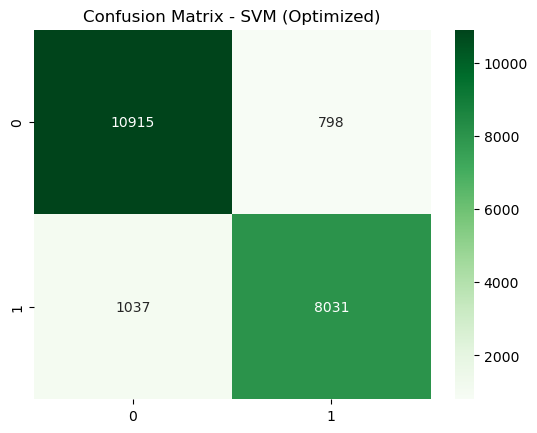

In [88]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - SVM (Optimized)')


ROC Curve:


Text(0.5, 1.0, 'ROC Curve - SVM (Optimized)')

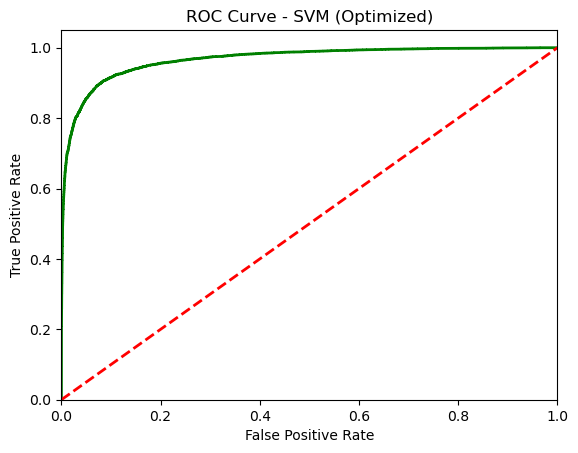

In [89]:
print('ROC Curve:')
y_proba_svm = best_svm.predict_proba(X_test_pca)[:, 1]
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_proba_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)
plt.figure()
plt.plot(fpr_svm, tpr_svm, color='green', lw=2, label=f'ROC curve (area = {roc_auc_svm:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM (Optimized)')

#### DECISION TREE MODELI

In [90]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [91]:
# Model definition
# Trees do not require scaling or PCA, so we proceed with the original X_train/X_test.
dt_model = DecisionTreeClassifier(random_state=42)

In [92]:
# Parameter Space
# Setting boundaries to prevent the tree from branching too much and overfitting
param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None], # Maximum depth of the tree
    'criterion': ['gini', 'entropy'], # Split criterion
    'min_samples_split': [2, 5, 10], # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4] # Minimum samples required at a leaf node
}

# 3. GridSearchCV (trees are fast enough to use full GridSearch))
grid_search_dt = GridSearchCV(
    dt_model, 
    param_grid=param_grid_dt, 
    cv=5, 
    n_jobs=-1, 
    verbose=1
)

In [93]:
grid_search_dt.fit(X_train, y_train)

print(f"Best Parameters: {grid_search_dt.best_params_}")

Fitting 5 folds for each of 90 candidates, totalling 450 fits


Best Parameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10}


In [94]:
best_dt = grid_search_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)

In [95]:
print("--- Decision Tree (Optimized) Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_dt):.4f}")


--- Decision Tree (Optimized) Results ---
Accuracy: 0.9539

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96     11713
           1       0.96      0.93      0.95      9068

    accuracy                           0.95     20781
   macro avg       0.95      0.95      0.95     20781
weighted avg       0.95      0.95      0.95     20781

ROC AUC: 0.9518


Confusion Matrix:
[[10134  1579]
 [ 2027  7041]]


Text(0.5, 1.0, 'Confusion Matrix - Decision Tree (Optimized)')

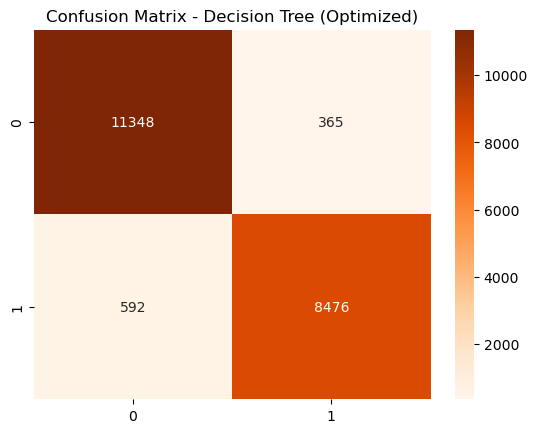

In [96]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - Decision Tree (Optimized)')


ROC Curve:


Text(0.5, 1.0, 'ROC Curve - DT (Optimized)')

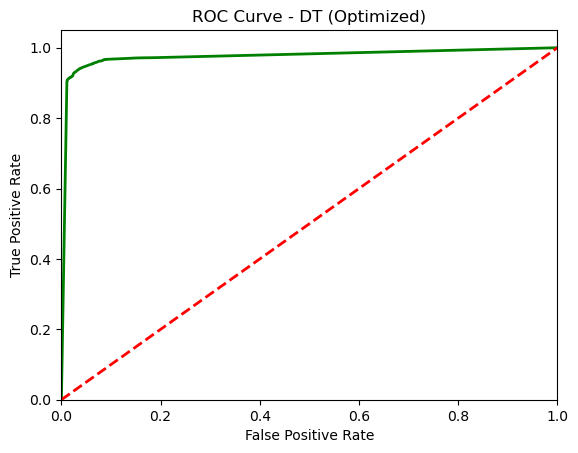

In [97]:
print('ROC Curve:')
y_proba_dt = best_dt.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_proba_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)
plt.figure()
plt.plot(fpr_dt, tpr_dt, color='green', lw=2, label=f'ROC curve (area = {roc_auc_dt:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')   
plt.title('ROC Curve - DT (Optimized)')

#### RANDOM FOREST MODELI

In [98]:
# Model definition
rf_model = RandomForestClassifier(random_state=42)

In [99]:
# Parameter Space
param_dist_rf = {
    'n_estimators': [100, 200, 300], # Number of trees
    'max_depth': [10, 20, 30, None], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum samples required to split a node
    'max_features': ['sqrt', 'log2'] # Number of features considered at each split
}

In [100]:
# Randomized Search
# We will try 10 different combinations with n_iter=10.
random_search_rf = RandomizedSearchCV(
    rf_model, 
    param_distributions=param_dist_rf, 
    n_iter=10, 
    cv=3, 
    n_jobs=-1, 
    verbose=2, 
    random_state=42
)

In [101]:
random_search_rf.fit(X_train, y_train)
print(f"Best Parameters: {random_search_rf.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=20, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   6.0s
[CV] END max_depth=20, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   6.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=200; total time=   9.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=200; total time=   9.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=200; total time=   9.4s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   4.8s
[CV] END max_depth=20, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   6.5s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   4.8s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   4.7s
[CV] END max_depth=None, max_features=s

In [102]:
# Feature Importance for Random Forest
best_rf = random_search_rf.best_estimator_
importances = best_rf.feature_importances_
feature_names = X_train.columns

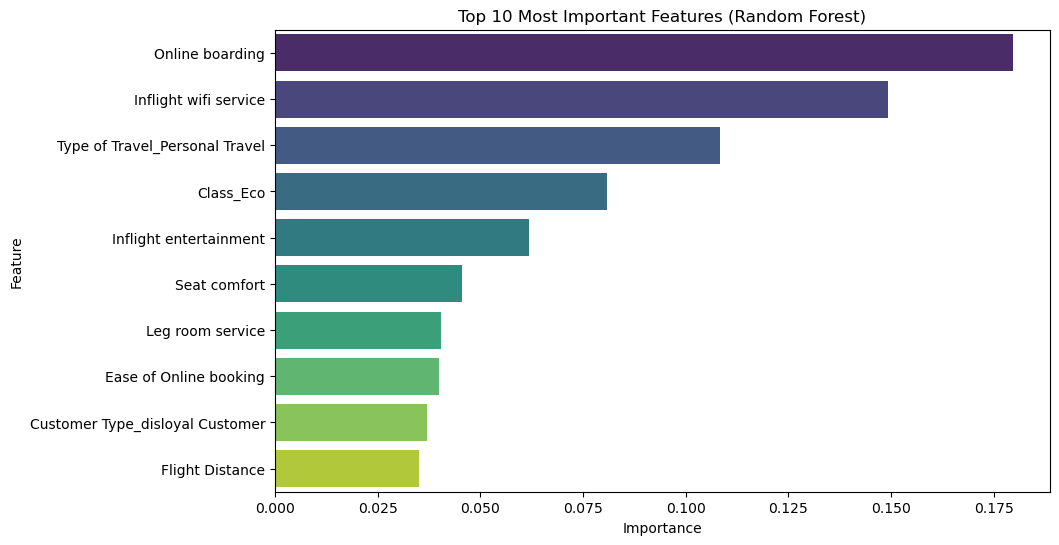

In [103]:
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.show()

In [104]:
print('Random Forest (Optimized) Results:')
y_pred_rf = best_rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:\n", classification_report(y_test,
y_pred_rf))
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_rf):.4f}")


Random Forest (Optimized) Results:
Accuracy: 0.9621

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97     11713
           1       0.97      0.94      0.96      9068

    accuracy                           0.96     20781
   macro avg       0.96      0.96      0.96     20781
weighted avg       0.96      0.96      0.96     20781

ROC AUC: 0.9596


Confusion Matrix:
[[10134  1579]
 [ 2027  7041]]


Text(0.5, 1.0, 'Confusion Matrix - Random Forest (Optimized)')

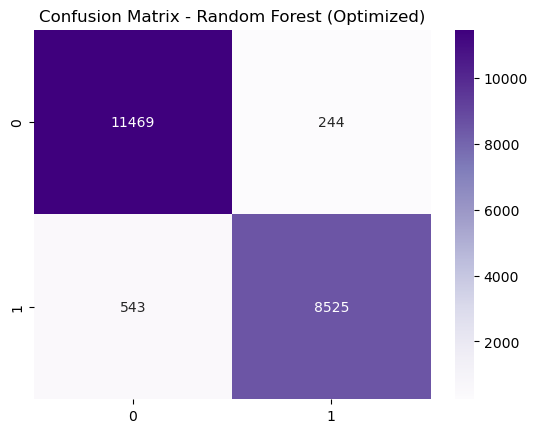

In [105]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - Random Forest (Optimized)')


ROC Curve:


Text(0.5, 1.0, 'ROC Curve - Random Forest (Optimized)')

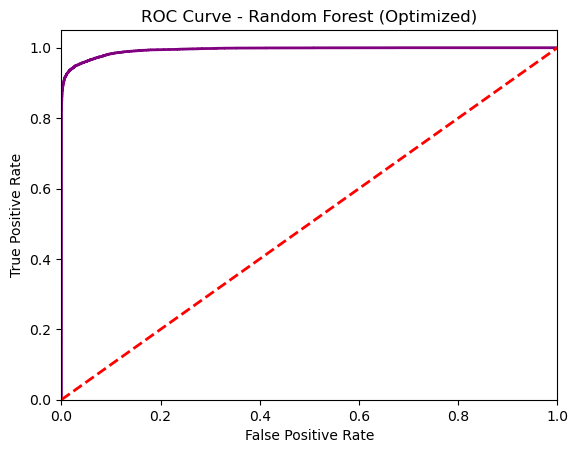

In [106]:
print('ROC Curve:')
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.figure()
plt.plot(fpr_rf, tpr_rf, color='purple', lw=2, label=f'ROC curve (area = {roc_auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw
=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest (Optimized)')

#### XGBOOST 

In [108]:
from xgboost import XGBClassifier
# Model definition
# use_label_encoder=False and eval_metric are added to suppress warnings
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

In [109]:
# Parameter Space
# learning_rate: How much each tree corrects the error (lower is better but requires more trees)
# max_depth: Depth of each tree (generally 3-10 is ideal)
param_dist_xgb = {
    'n_estimators': [100, 300, 500], # Number of trees
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # How much each tree corrects the error (lower is better but requires more trees)
    'max_depth': [3, 6, 9], # Tree depth (generally 3-10 is ideal)
    'subsample': [0.8, 1.0],      # Fraction of data used per tree
    'colsample_bytree': [0.8, 1.0] # Fraction of features used per split
}


In [110]:
# Randomized Search
random_search_xgb = RandomizedSearchCV(
    xgb_model, 
    param_distributions=param_dist_xgb, 
    n_iter=10, 
    cv=3, 
    n_jobs=-1, 
    verbose=2, 
    random_state=42
)

In [111]:
random_search_xgb.fit(X_train, y_train)

print(f"Best Parameters: {random_search_xgb.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=6, n_estimators=100, subsample=1.0; total time=   0.7s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=6, n_estimators=100, subsample=1.0; total time=   0.7s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=6, n_estimators=300, subsample=1.0; total time=   1.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=6, n_estimators=300, subsample=1.0; total time=   1.6s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=6, n_estimators=300, subsample=1.0; total time=   1.6s
[CV] END colsa

[14:23:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [112]:
best_xgb = random_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print("--- XGBoost (Optimized) Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_xgb):.4f}")

--- XGBoost (Optimized) Results ---
Accuracy: 0.9635

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97     11713
           1       0.97      0.94      0.96      9068

    accuracy                           0.96     20781
   macro avg       0.96      0.96      0.96     20781
weighted avg       0.96      0.96      0.96     20781

ROC AUC: 0.9612


Confusion Matrix:


Text(0.5, 1.0, 'Confusion Matrix - XGBoost (Optimized)')

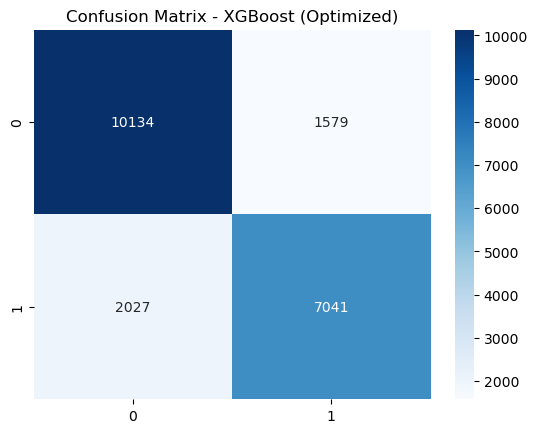

In [113]:
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost (Optimized)')


ROC Curve:


Text(0.5, 1.0, 'ROC Curve - XGBoost (Optimized)')

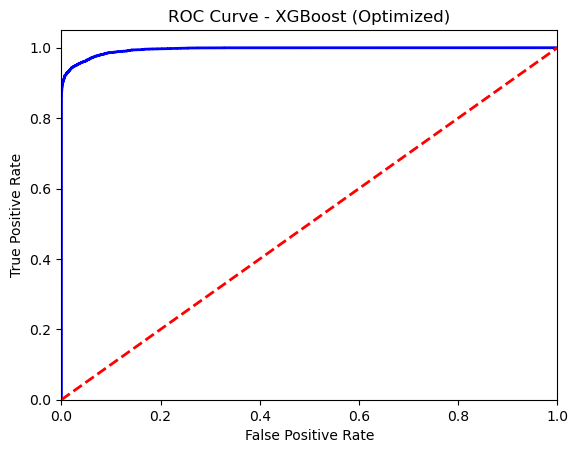

In [114]:
print('ROC Curve:')
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.figure()
plt.plot(fpr_xgb, tpr_xgb, color='blue', lw=2, label=f'ROC curve (area = {roc_auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw
=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost (Optimized)')

#### MLP

In [115]:
from sklearn.neural_network import MLPClassifier

In [116]:
# Model definition
# Using PCA data (12 components) allows MLP to converge much faster
mlp_model = MLPClassifier(max_iter=500, random_state=42)

In [117]:
# Parameter Space
param_dist_mlp = {
    'hidden_layer_sizes': [(64, 32), (100,), (50, 50, 50)], # Layer and neuron counts
    'activation': ['tanh', 'relu'],                        # Activation function
    'solver': ['adam', 'sgd'],                             # Optimization algorithm
    'alpha': [0.0001, 0.05],                               # L2 regularization (for overfitting)
    'learning_rate': ['constant', 'adaptive'],
}

In [118]:
#Randomized Search
random_search_mlp = RandomizedSearchCV(
    mlp_model, 
    param_distributions=param_dist_mlp, 
    n_iter=5, 
    cv=3, 
    n_jobs=-1, 
    verbose=2, 
    random_state=42
)

In [119]:
# Using PCA data!
random_search_mlp.fit(X_train_pca, y_train)

print(f"Best Parameters: {random_search_mlp.best_params_}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END activation=relu, alpha=0.05, hidden_layer_sizes=(100,), learning_rate=constant, solver=adam; total time=  17.0s
[CV] END activation=relu, alpha=0.05, hidden_layer_sizes=(100,), learning_rate=constant, solver=adam; total time=  19.8s
[CV] END activation=relu, alpha=0.05, hidden_layer_sizes=(100,), learning_rate=constant, solver=adam; total time=  21.8s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(64, 32), learning_rate=adaptive, solver=adam; total time=  37.8s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(64, 32), learning_rate=adaptive, solver=adam; total time=  44.7s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(64, 32), learning_rate=adaptive, solver=adam; total time=  46.5s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(64, 32), learning_rate=adaptive, solver=sgd; total time= 1.4min
[CV] END activation=relu, alpha=0.05, hidden_layer_sizes=(100,), learning_rate

In [120]:
best_mlp = random_search_mlp.best_estimator_
y_pred_mlp = best_mlp.predict(X_test_pca)

print("--- MLP (Optimized) Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_mlp):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_mlp))
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_mlp):.4f}")


--- MLP (Optimized) Results ---
Accuracy: 0.9288

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.94     11713
           1       0.94      0.90      0.92      9068

    accuracy                           0.93     20781
   macro avg       0.93      0.93      0.93     20781
weighted avg       0.93      0.93      0.93     20781

ROC AUC: 0.9252


Confusion Matrix:


Text(0.5, 1.0, 'Confusion Matrix - MLP (Optimized)')

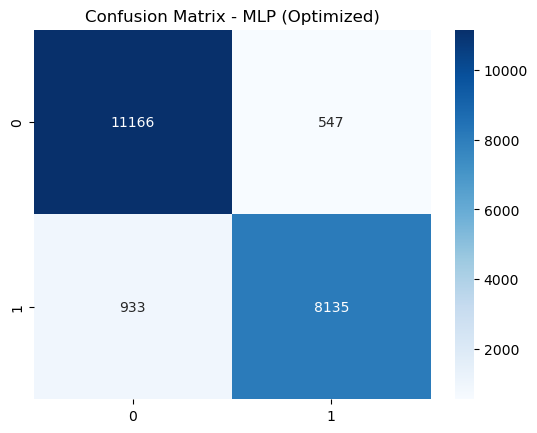

In [121]:
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_mlp), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - MLP (Optimized)')

ROC Curve:


Text(0.5, 1.0, 'ROC Curve - MLP (Optimized)')

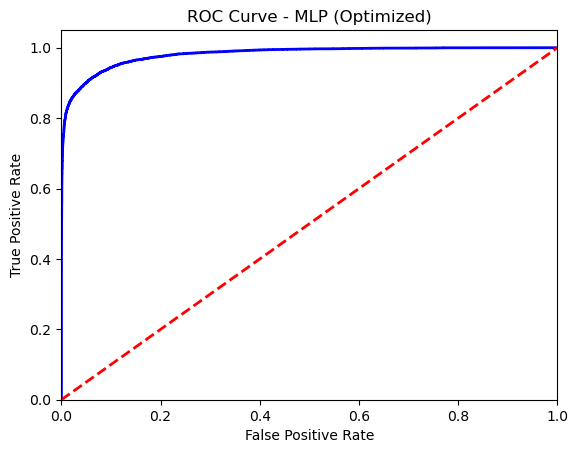

In [122]:
print('ROC Curve:')
y_proba_mlp = best_mlp.predict_proba(X_test_pca)[:, 1]
fpr_mlp, tpr_mlp, thresholds_mlp = roc_curve(y_test, y_proba_mlp)
roc_auc_mlp = auc(fpr_mlp, tpr_mlp)
plt.figure()
plt.plot(fpr_mlp, tpr_mlp, color='blue', lw=2, label=f'ROC curve (area = {roc_auc_mlp:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - MLP (Optimized)')

In [123]:
performance_metrics = []

def evaluate_model(model_name, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    
    performance_metrics.append({
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })
    
    print(f"{model_name} evaluated.")


In [124]:
evaluate_model("Logistic Regression", y_test, y_pred, y_proba)
evaluate_model("SVM", y_test, y_pred_svm, y_proba_svm)
evaluate_model("Decision Tree", y_test, y_pred_dt, y_proba_dt)
evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb, y_proba_xgb)
evaluate_model("MLP", y_test, y_pred_mlp, y_proba_mlp)

Logistic Regression evaluated.
SVM evaluated.
Decision Tree evaluated.
Random Forest evaluated.
XGBoost evaluated.
MLP evaluated.



--- COMPARATIVE PERFORMANCE OF ALL MODELS ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
4,XGBoost,0.9635,0.9728,0.9428,0.9575,0.9950
3,Random Forest,0.9621,0.9722,0.9401,0.9559,0.9939
5,MLP,0.9288,0.9370,0.8971,0.9166,0.9810
2,Decision Tree,0.9539,0.9587,0.9347,0.9466,0.9752
1,SVM,0.9117,0.9096,0.8856,0.8975,0.9669
0,Logistic Regression,0.8265,0.8168,0.7765,0.7961,0.8870


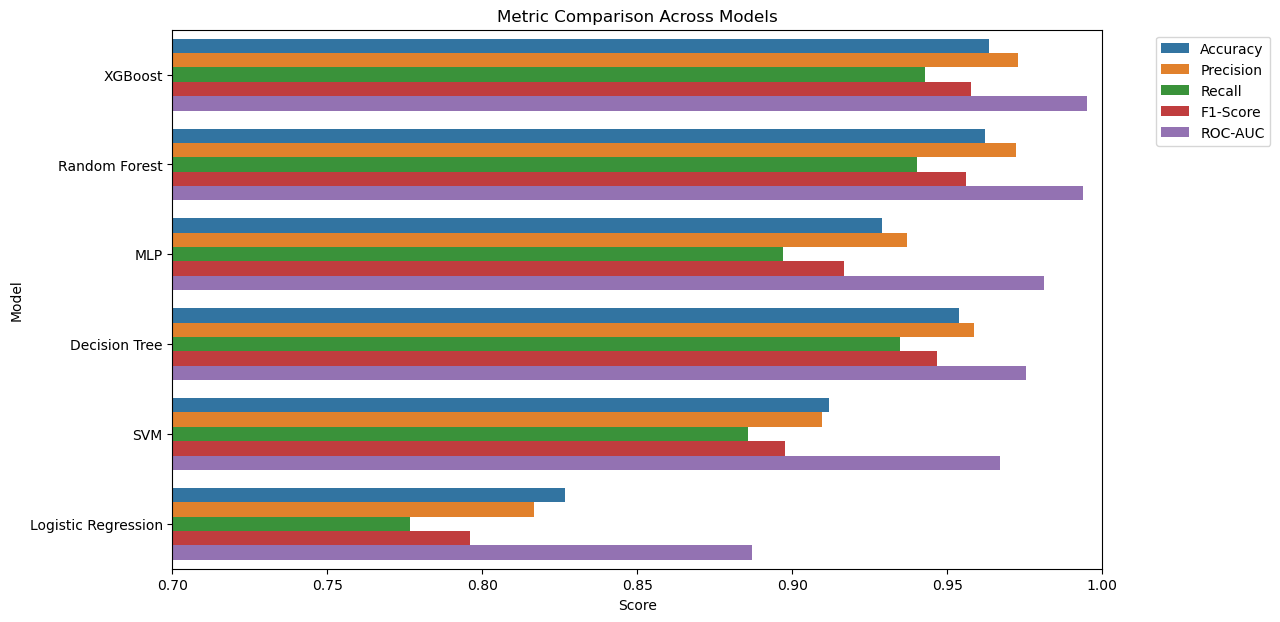

In [125]:
comparison_df = pd.DataFrame(performance_metrics).sort_values(by='ROC-AUC', ascending=False)

print("\n--- COMPARATIVE PERFORMANCE OF ALL MODELS ---")
display(comparison_df)

plt.figure(figsize=(12, 7))
melted_df = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(x='Score', y='Model', hue='Metric', data=melted_df)
plt.title('Metric Comparison Across Models')
plt.xlim(0.7, 1.0) # Lower bound set to 70% to better visualize differences
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Model Performance Analysis and Interpretation
### 1. General Evaluation

Among the models analyzed, XGBoost achieved the highest performance across all metrics (Accuracy, F1-Score, ROC-AUC) and was selected as the final model for the project. An accuracy of 96.35% demonstrates that the model is highly reliable for predicting airline passenger satisfaction.

#### Linear vs. Non-Linear Models

    Logistic Regression (82.65%): Its lowest performance indicates that the relationships between factors affecting passenger satisfaction are not simple and linear, but rather complex and intertwined.

    Tree-Based Models (XGBoost, RF, DT): Scoring 95% and above proves that they capture hierarchical relationships in the dataset much more effectively (e.g., the varying importance of Wi-Fi for Business Class passengers).

#### Model Reliability (ROC-AUC Focused)

The ROC-AUC scores of XGBoost and Random Forest at the 0.99 level show that these models perform nearly flawlessly when distinguishing between "Satisfied" and "Dissatisfied" classes. This means the model operates with very low error rates even at different threshold values.

#### Precision and Recall Balance

Across all models, the Precision value (97.28% - XGB) being slightly higher than the Recall value (94.28% - XGB) indicates that our models are very confident when they predict "Satisfied", but may occasionally miss a small number of passengers who are actually satisfied.

#### Strategic Recommendations

    Critical Service Points: If "Inflight wifi service", "Online boarding", and "Type of Travel" emerge as the most important variables in the XGBoost analysis (as expected), directing company resources toward improving these digital processes will have the greatest impact on increasing customer loyalty (satisfaction).

    Segmentation: The weak performance of Logistic Regression confirms that passengers do not fit a single profile; Business and Eco class passengers have different expectations.